In [1]:
import os
import pickle
import sys
sys.path.append("/data1/morrisq/divyak/projects/metient/notebooks/lineage_tracing")
import lineage_tracing_utilities as lt
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

output_dir = "/data1/morrisq/divyak/projects/metient/notebooks/outputs"

# Change this to where reproducibility data is stored (Download here: https://github.com/divyakoyy/metient_reproducibility)
DATA_DIR = "/data1/morrisq/divyak/data/metient_reproducibility/lung_lineage_tracing"

metient_results_dir = os.path.join(DATA_DIR, "metient_outputs")


### Visualize a labeling from Fitch-Hartigan small parsimony solution for clone 99

DiGraph with 43 nodes and 42 edges
Total migrations: 8
mig_graph_no_diag
 tensor([[0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [1., 0., 2., 2., 0., 0.],
        [0., 0., 0., 0., 0., 0.]])


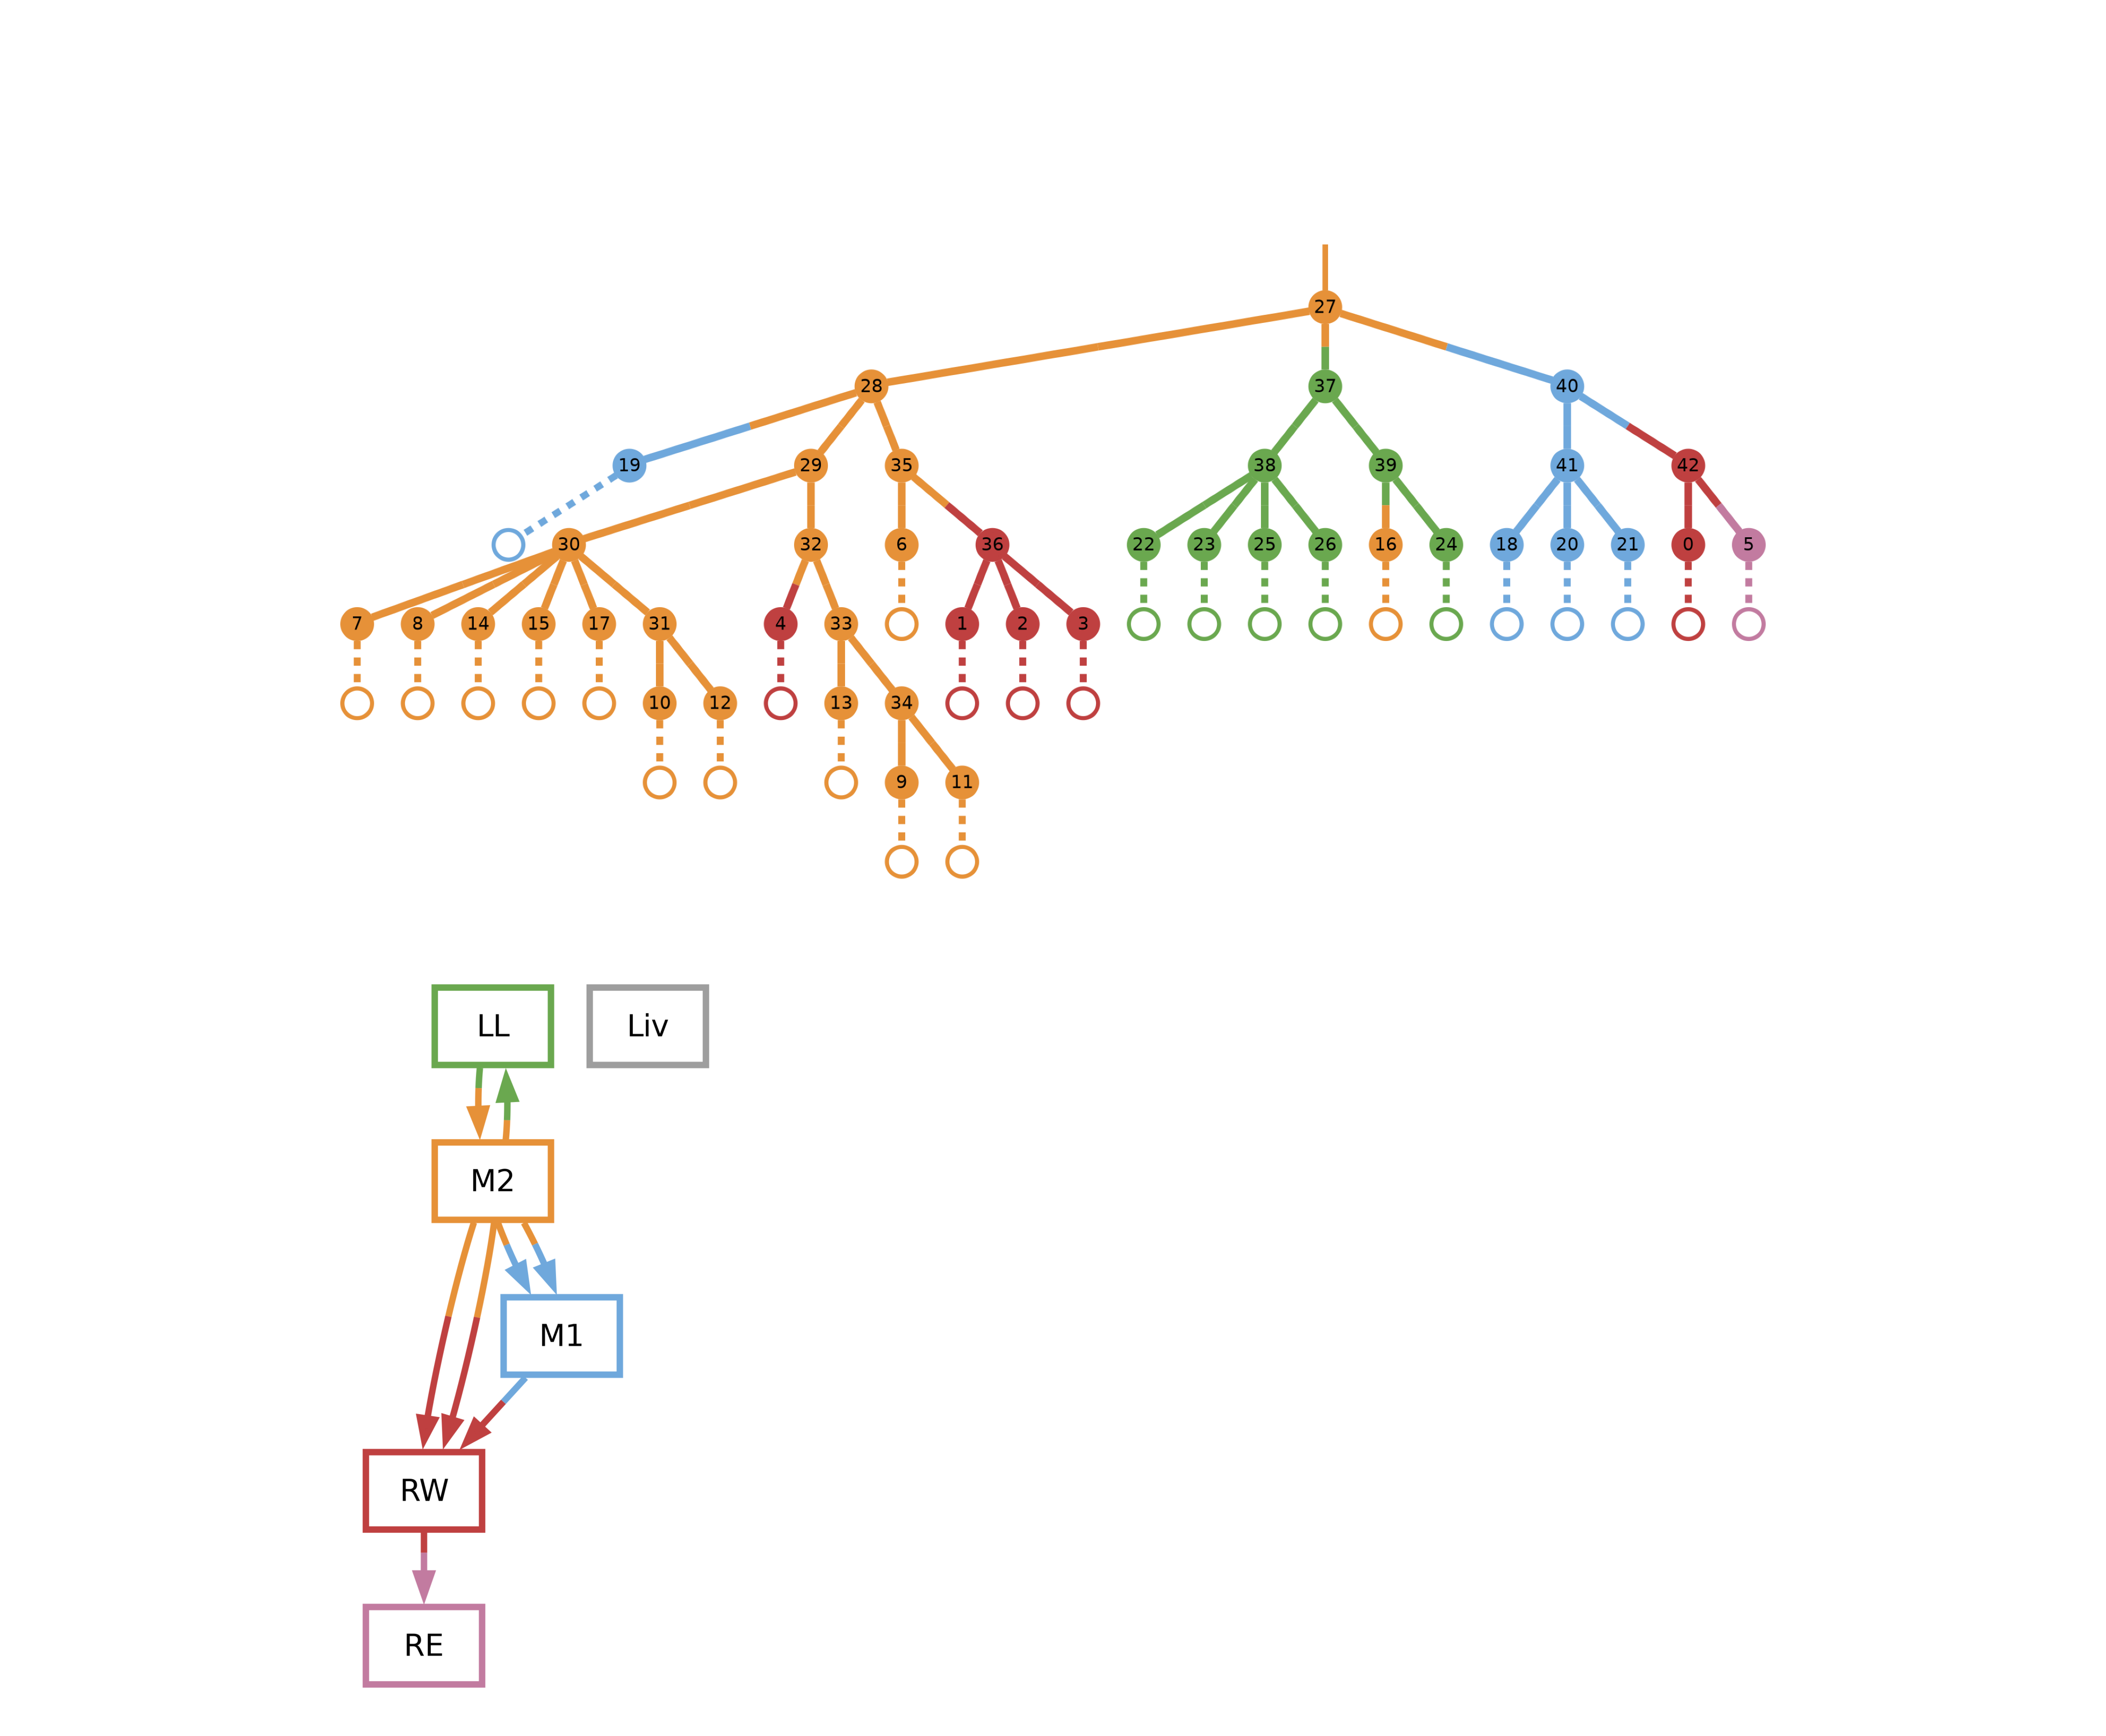

In [2]:
cass_results_dir = os.path.join(DATA_DIR, "cassiopeia_outputs")

with open(os.path.join(cass_results_dir,'vanilla_greedy_cas_random_min_mig_history.pkl'), 'rb') as f:
    fitch_min_mig_history = pickle.load(f)

clone=99
with open(os.path.join(cass_results_dir,f'{clone}_vanilla_cas_networkx.pkl'), 'rb') as f:
    G = pickle.load(f)
G.remove_node("primary")
print(G)
lt.plot_nx_tree(fitch_min_mig_history[clone], G, f"{clone}_fitch_count_random_history")

### Load migration histories

In [3]:
import gzip
import numpy.core.numeric
# alias old module path → new one
sys.modules['numpy._core.numeric'] = numpy.core.numeric

clones = [int(f[:-len('_LL.pkl.gz')]) for f in os.listdir(metient_results_dir) if f.endswith('_LL.pkl.gz')]
clones = sorted(clones)
print(len(clones), "clones")

def consensus_migration_graph_over_clones(scaled_migration_graphs):
    # Sum all normalized migration graphs with equal weights
    consensus_migrations = torch.zeros_like(scaled_migration_graphs[0])
    for graph in scaled_migration_graphs:
        consensus_migrations += graph
    
    # Normalize by dividing by total sum to make everything sum to 1
    total_sum = consensus_migrations.sum()
    # Handle case where sum is 0 to avoid division by zero
    total_sum = total_sum if total_sum != 0 else 1.0
    consensus_migrations = consensus_migrations / total_sum
    return consensus_migrations

with open(os.path.join(cass_results_dir,'vanilla_greedy_cas_unnormalized_tissue_transitions.pkl'), 'rb') as f:
    fitch_tissue_trans_data = pickle.load(f)

with open(os.path.join(cass_results_dir,'vanilla_greedy_cas_min_mig_score.pkl'), 'rb') as f:
    fitch_min_mig_scores = pickle.load(f)

clone_to_metient_tree_met_rate = {}
clone_to_fitch_tree_met_rate = {}

for clone in fitch_min_mig_scores:
    with open(os.path.join(cass_results_dir,f'{clone}_vanilla_cas_networkx.pkl'), 'rb') as f:
        G = pickle.load(f)
    edges = G.number_of_edges()
    clone_to_fitch_tree_met_rate[clone] = fitch_min_mig_scores[clone]/edges

met_scaled_migration_graphs = []
fitch_scaled_migration_graphs = []
for clone in clones:
    print(f"\nclone {clone}")

    _, weighted_scaled_tissue_trans, pars_metrics, mig_graphs = lt.extract_info(metient_results_dir, clone)
    with open(os.path.join(cass_results_dir,f'{clone}_vanilla_cas_networkx.pkl'), 'rb') as f:
        G = pickle.load(f)
    
    edges = G.number_of_edges()
    clone_to_metient_tree_met_rate[clone] = pars_metrics[0][0]/edges
    
    met_scaled_migration_graphs.append(weighted_scaled_tissue_trans)

    fitch_tissue_trans = lt.extract_scaled_fitch_tissue_trans(fitch_tissue_trans_data, clone)
    fitch_scaled_migration_graphs.append(fitch_tissue_trans)

met_consensus_migrations = consensus_migration_graph_over_clones(met_scaled_migration_graphs)
fitch_consensus_migrations = consensus_migration_graph_over_clones(fitch_scaled_migration_graphs)

100 clones

clone 1
26 solutions

clone 2


/data1/morrisq/divyak/projects/metient/metient/util/data_extraction_util.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parents = torch.tensor(parents)[mask]


42 solutions

clone 3
19 solutions

clone 4
32 solutions

clone 5
22 solutions

clone 6
38 solutions

clone 7
29 solutions

clone 8
35 solutions

clone 9
47 solutions

clone 10
20 solutions

clone 11
27 solutions

clone 12
18 solutions

clone 13
22 solutions

clone 14
19 solutions

clone 15
17 solutions

clone 16
17 solutions

clone 17
28 solutions

clone 18
3 solutions

clone 19
6 solutions

clone 20
14 solutions

clone 21
33 solutions

clone 22
1 solutions

clone 23
23 solutions

clone 24
31 solutions

clone 25
6 solutions

clone 26
19 solutions

clone 27
2 solutions

clone 28
14 solutions

clone 29
1 solutions

clone 30
21 solutions

clone 31
13 solutions

clone 32
4 solutions

clone 33
31 solutions

clone 34
13 solutions

clone 35
3 solutions

clone 36
5 solutions

clone 37
7 solutions

clone 38
7 solutions

clone 39
1 solutions

clone 40
2 solutions

clone 41
12 solutions

clone 42
2 solutions

clone 43
11 solutions

clone 44
4 solutions

clone 45
3 solutions

clone 46
1 solutions

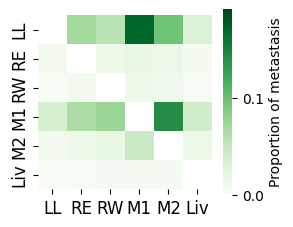

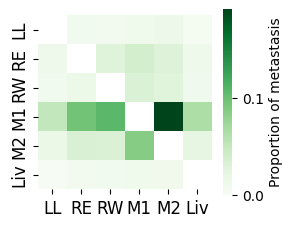

In [4]:
import math
def plot_overall_tissue_transiton(tissue_trans, max_val, method):
    # Overall tissue transition matrix
    tissue_trans = tissue_trans.clone()
    tissue_trans.fill_diagonal_(float('nan'))

    fig = plt.figure(figsize = (3,3))
    rounded_max_val = round(max_val * 20) / 20
    g = sns.heatmap(tissue_trans, cmap="Greens", square=True, vmin=0, vmax=max_val, 
                    cbar=True, cbar_kws={"label": "Proportion of metastasis", "ticks": [0, rounded_max_val/2, rounded_max_val], "shrink": 0.7})
    g.set_xticks([x+0.5 for x in range(len(lt.TISSUE_ORDER))],lt.TISSUE_ORDER, fontsize=12)
    g.set_yticks([x+0.5 for x in range(len(lt.TISSUE_ORDER))],lt.TISSUE_ORDER, fontsize=12)
    plt.subplots_adjust(hspace=0.7, wspace=0.1)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"consensus_migrations_{method}.svg"), dpi=500)
    plt.show()
    plt.close()

max_val = float(max(torch.max(met_consensus_migrations), torch.max(fitch_consensus_migrations)))
print()
plot_overall_tissue_transiton(met_consensus_migrations, max_val, "metient")
plot_overall_tissue_transiton(fitch_consensus_migrations, max_val, "fitch")
   
